Task 2: Customer Segmentation Analysis

In [ ]:
# Import Libraries & Load Data
import datetime as dt
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Load dataset from Google Colab local directory
df = pd.read_csv("/content/data.csv", encoding="ISO-8859-1")

# Standardize column names (strip whitespace)
df.columns = df.columns.str.strip()

# Handle dataset-specific columns if using the UCI Online Retail dataset
# Clean missing Customer IDs and negative quantities/prices if present
if "CustomerID" in df.columns:
  df = df.dropna(subset=["CustomerID"])
  df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]
  df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]
  df["Date"] = pd.to_datetime(df["InvoiceDate"])
  customer_col = "CustomerID"
  trans_col = "InvoiceNo"
  monetary_col = "TotalAmount"
else:
  # Fallback for Retail Sales dataset structure
  df["Date"] = pd.to_datetime(df["Date"])
  customer_col = "Customer ID"
  trans_col = "Transaction ID"
  monetary_col = "Total Amount"

print("Dataset loaded & cleaned successfully! Total records:", len(df))
display(df.head())

Dataset loaded & cleaned successfully! Total records: 397884


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount,Date
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,15.30,2010-12-01 08:26:00
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34,2010-12-01 08:26:00
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,22.00,2010-12-01 08:26:00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34,2010-12-01 08:26:00
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34,2010-12-01 08:26:00


In [ ]:
# Compute Recency, Frequency, and Monetary (RFM) Metrics
snapshot_date = df["Date"].max() + dt.timedelta(days=1)

# Group by Customer ID to build RFM dataframe
rfm = (
    df.groupby(customer_col)
    .agg(
        {
            "Date": lambda x: (snapshot_date - x.max()).days,  # Recency
            trans_col: "nunique"
            if "InvoiceNo" in df.columns
            else "count",  # Frequency
            monetary_col: "sum",  # Monetary
        }
    )
    .reset_index()
)

rfm.columns = ["Customer_ID", "Recency", "Frequency", "Monetary"]

print("--- RFM Summary ---")
display(rfm.head())

--- RFM Summary ---


,Customer_ID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


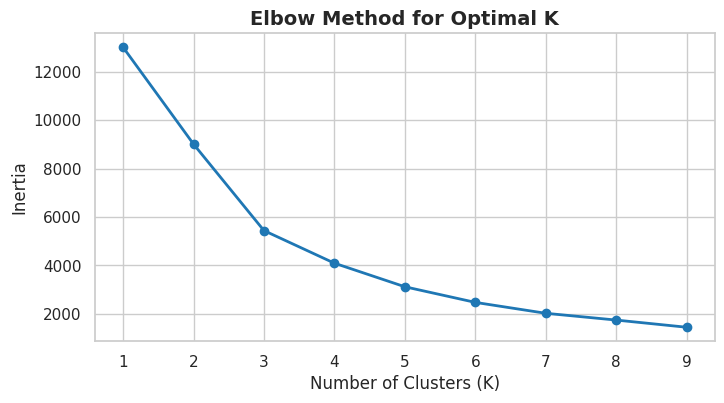

In [ ]:
# Scale Features & Apply K-Means
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[["Recency", "Frequency", "Monetary"]])

# Determine optimal K using Elbow Method
inertia = []
K_range = range(1, 10)
for k in K_range:
  kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
  kmeans.fit(rfm_scaled)
  inertia.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, marker="o", color="#1f77b4", linewidth=2)
plt.title("Elbow Method for Optimal K", fontsize=14, fontweight="bold")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.show()

# Fit K-Means with K=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

# Map clusters to persona labels
cluster_labels = {
    0: "Moderate Value / Regular",
    1: "High-Value / Loyal",
    2: "At-Risk / Low Spending",
}
rfm["Segment"] = rfm["Cluster"].map(cluster_labels)

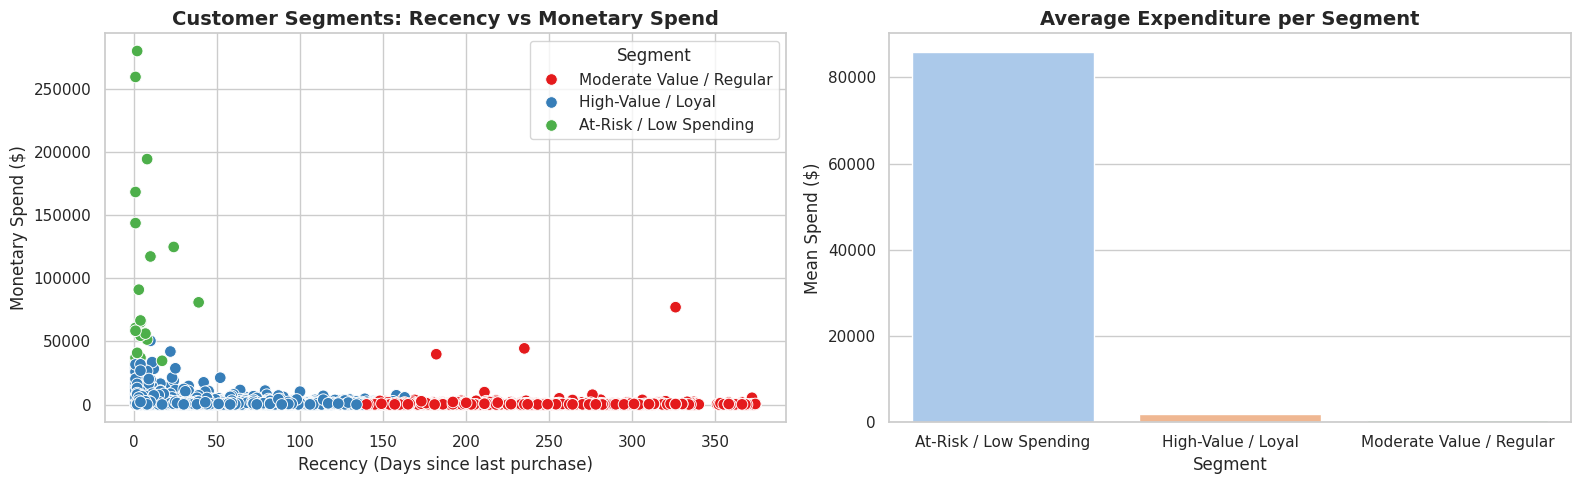


--- Mean RFM Summary per Segment ---


,Segment,Recency,Frequency,Monetary
0,At-Risk / Low Spending,6.04,66.42,85904.35
1,High-Value / Loyal,41.45,4.67,1855.94
2,Moderate Value / Regular,247.11,1.58,631.42


In [ ]:
# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Scatter plot: Recency vs Monetary
sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Monetary",
    hue="Segment",
    palette="Set1",
    s=70,
    ax=axes[0],
)
axes[0].set_title(
    "Customer Segments: Recency vs Monetary Spend",
    fontsize=14,
    fontweight="bold",
)
axes[0].set_xlabel("Recency (Days since last purchase)")
axes[0].set_ylabel("Monetary Spend ($)")

# Bar plot: Average Spend per Segment
segment_means = (
    rfm.groupby("Segment", observed=False)[
        ["Recency", "Frequency", "Monetary"]
    ]
    .mean()
    .reset_index()
)
sns.barplot(
    data=segment_means,
    x="Segment",
    y="Monetary",
    palette="pastel",
    hue="Segment",
    ax=axes[1],
    legend=False,
)
axes[1].set_title(
    "Average Expenditure per Segment", fontsize=14, fontweight="bold"
)
axes[1].set_ylabel("Mean Spend ($)")

plt.tight_layout()
plt.show()

print("\n--- Mean RFM Summary per Segment ---")
display(segment_means.round(2))

### 📌 Actionable Business Recommendations for Customer Segments

1. **VIP Loyalty & Exclusive Perks (High-Value / Loyal):**
   * Retain top-tier customers with early access to new product releases, exclusive rewards, and dedicated customer service channels.

2. **Win-Back Campaigns (At-Risk / Low Spending):**
   * Re-engage inactive buyers who have high recency values by sending automated email offers with personalized discounts.

3. **Cross-Selling & Upselling (Moderate Value / Regular):**
   * Recommend complementary product bundles to encourage moderate spenders to cross higher monetary thresholds.